# Student Performance — Corrected, Reproducible Pipeline

This is a cleaned rebuild of the original notebook. It fixes:

- **Target leakage** — trains two feature sets side by side: `full` (uses term
  grades, high accuracy but leaky) and `early` (no grades, an honest early-warning
  model using only what's knowable before the exam).
- **Class-label bug** — class names are always read from the fitted model, never
  hardcoded, so reports can't be silently swapped.
- **Wrong saved models** — each fitted pipeline is saved to its own correctly named
  file.
- **Train-only evaluation** — every model is scored on a held-out test set, against
  a majority-class **baseline**, with FAIL recall and PR-AUC (the metrics that
  actually matter for catching at-risk students).
- **Reproducibility** — configurable data path (no hardcoded machine paths), fixed
  random state, class balancing on.

Requires: `pandas`, `scikit-learn>=1.2`, `seaborn`, `matplotlib`, `joblib`, `openpyxl`.

## 1. Config

In [1]:
from pathlib import Path

# Point this at your data file (xlsx or csv). Update for your machine.
DATA_PATH   = Path("updated_data.xlsx")
TARGET      = "waec"
ID_COLS     = ["student_id", "parent_id"]
DROP_COLS   = ["score_band"]     # a band derived from the grades -> leakage, drop it
POS_LABEL   = "FAIL"             # the at-risk class we most want to catch
RANDOM_STATE = 42
TEST_SIZE    = 0.30

## 2. Load

In [2]:
import pandas as pd

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Couldn't find {DATA_PATH.resolve()}. "
        "Update DATA_PATH in the config cell."
    )

if DATA_PATH.suffix.lower() in {".xlsx", ".xls"}:
    df = pd.read_excel(DATA_PATH)
else:
    df = pd.read_csv(DATA_PATH)

assert TARGET in df.columns, f"TARGET '{TARGET}' not found. Columns: {list(df.columns)}"
print("Shape:", df.shape)
df.head()

Shape: (382, 44)


,student_id,sex,age,address,famsize,reason,guardian,romantic_rel,health_status,absences,...,biology_term2,biology_term3,biology_avg,yoruba_term1,yoruba_term2,yoruba_term3,yoruba_avg,failures,score_band,waec
0,STU0000,F,18,U,GT3,course,mother,no,3,6,...,2,8,5.7,8,0,4,4.0,0,low,FAIL
1,STU0001,F,17,U,GT3,course,father,no,3,4,...,4,2,3.7,7,10,9,8.7,0,low,FAIL
2,STU0002,F,15,U,LE3,other,mother,no,3,10,...,5,11,9.7,13,12,12,12.3,3,mid,PASS
3,STU0003,F,15,U,GT3,home,mother,yes,5,2,...,12,13,14.0,17,15,6,12.7,0,high,PASS
4,STU0004,F,16,U,GT3,home,father,no,5,4,...,12,7,8.0,11,13,14,12.7,0,mid,PASS


### Data provenance

This notebook runs on `updated_data.xlsx`, an **adapted** version of the public UCI
Student Performance dataset (Cortez & Silva, 2008; CC BY 4.0): columns were renamed
and the per-subject term grades were synthesized from the original period grades
(G1/G2/G3). That adapted file is committed to the repo and loaded above — it is not
retrievable from Kaggle as-is, so a programmatic Kaggle pull would return a different
schema.

Appendix A (bottom of the notebook) shows how to fetch the **original** source data
for lineage/reference only. It does **not** feed the pipeline.

## 3. Quick EDA + sanity checks

In [3]:
print("Target distribution:")
print(df[TARGET].value_counts())

majority = df[TARGET].value_counts(normalize=True).max()
print(f"\nMajority-class share (naive baseline accuracy): {majority:.3f}")

if POS_LABEL not in set(df[TARGET].unique()):
    print(f"\nWARNING: POS_LABEL '{POS_LABEL}' not in {sorted(df[TARGET].unique())}. "
          "Update POS_LABEL in the config cell.")

miss = df.isna().sum()
print("\nColumns with missing values:")
print(miss[miss > 0] if miss.any() else "none")

Target distribution:
waec
PASS    272
FAIL    110
Name: count, dtype: int64

Majority-class share (naive baseline accuracy): 0.712

Columns with missing values:
none


## 4. Feature sets

`full` uses the term grades (leaky). `early` drops **all** grade columns and keeps
only demographics, behaviour, and prior `failures` — the honest early-warning setup.
We also drop the `*_avg` columns from `full` because each average is a linear
combination of its three term scores (perfect multicollinearity).

In [4]:
grade_cols = [c for c in df.columns if c.endswith(("_term1","_term2","_term3","_avg"))]
avg_cols   = [c for c in df.columns if c.endswith("_avg")]
term1_cols = [c for c in df.columns if c.endswith("_term1")]

exclude = set(ID_COLS + DROP_COLS + [TARGET])

full_features  = [c for c in df.columns if c not in exclude and c not in avg_cols]
early_features = [c for c in df.columns if c not in exclude and c not in grade_cols]
early_term1_features = early_features + term1_cols  # optional middle ground

FEATURE_SETS = {
    "full":  full_features,
    "early": early_features,
    # "early_term1": early_term1_features,   # uncomment to experiment
}

for name, feats in FEATURE_SETS.items():
    print(f"{name:6s}: {len(feats)} features")

full  : 36 features
early : 24 features


## 5. Preprocessing + models

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def build_preprocessor(frame, features):
    # Split by dtype without select_dtypes(include="object"), which is deprecated
    # in pandas 3 for string columns. is_numeric_dtype is stable across versions.
    num = [c for c in features if pd.api.types.is_numeric_dtype(frame[c])]
    cat = [c for c in features if c not in num]
    return ColumnTransformer([
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat),
        ("scaler", StandardScaler(), num),
    ])

In [6]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV

def make_models():
    # class_weight='balanced' addresses the imbalance. MLP has no such option.
    return {
        "LogisticRegression": LogisticRegression(
            C=0.1, solver="lbfgs", max_iter=1000,
            class_weight="balanced", random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(
            class_weight="balanced", random_state=RANDOM_STATE),
        # PR-AUC needs predict_proba. SVC(probability=True) is deprecated in
        # sklearn 1.9 (removed in 1.11), so calibrate explicitly instead.
        "SVM": CalibratedClassifierCV(
            SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE),
            ensemble=False),
        "MLP": MLPClassifier(
            hidden_layer_sizes=(100,), max_iter=1000, random_state=RANDOM_STATE),
        "SGD": SGDClassifier(
            loss="log_loss", class_weight="balanced", random_state=RANDOM_STATE),
    }

## 6. Evaluation helpers

In [7]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, recall_score, f1_score,
                             average_precision_score)

def pos_scores(model, X):
    """Score for POS_LABEL, for PR-AUC. Uses proba if available, else decision_function."""
    classes = list(model.classes_)
    i = classes.index(POS_LABEL)
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)[:, i]
    if hasattr(model, "decision_function"):
        d = model.decision_function(X)
        return d if classes[1] == POS_LABEL else -d
    return None

def evaluate(name, estimator, X_tr, X_te, y_tr, y_te):
    estimator.fit(X_tr, y_tr)
    y_pred = estimator.predict(X_te)
    s = pos_scores(estimator, X_te)
    row = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        f"recall_{POS_LABEL}": recall_score(y_te, y_pred, pos_label=POS_LABEL, zero_division=0),
        "macro_f1": f1_score(y_te, y_pred, average="macro"),
        f"pr_auc_{POS_LABEL}": (average_precision_score((y_te == POS_LABEL).astype(int), s)
                                if s is not None else np.nan),
    }
    return row, y_pred, estimator

def split(feats):
    X, y = df[feats], df[TARGET]
    return train_test_split(X, y, test_size=TEST_SIZE,
                            random_state=RANDOM_STATE, stratify=y)

## 7. Train + compare all models on both feature sets

In [8]:
import warnings
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results, fitted = [], {}
warnings.filterwarnings("ignore")   # cosmetic convergence notices; results unaffected

for fs_name, feats in FEATURE_SETS.items():
    X_tr, X_te, y_tr, y_te = split(feats)

    base_pipe = Pipeline([("prep", build_preprocessor(df, feats)),
                          ("clf", DummyClassifier(strategy="most_frequent"))])
    row, _, _ = evaluate("Baseline(most_frequent)", base_pipe, X_tr, X_te, y_tr, y_te)
    row["feature_set"] = fs_name
    results.append(row)

    for m_name, model in make_models().items():
        pipe = Pipeline([("prep", build_preprocessor(df, feats)), ("clf", model)])
        row, y_pred, fit = evaluate(m_name, pipe, X_tr, X_te, y_tr, y_te)
        cv = cross_val_score(pipe, X_tr, y_tr, cv=skf, scoring="accuracy")
        row.update(feature_set=fs_name, cv_acc_mean=cv.mean(), cv_acc_std=cv.std())
        results.append(row)
        fitted[(fs_name, m_name)] = fit

cols = ["feature_set","model","accuracy",f"recall_{POS_LABEL}","macro_f1",
        f"pr_auc_{POS_LABEL}","cv_acc_mean","cv_acc_std"]
results_df = (pd.DataFrame(results)[cols]
              .sort_values(["feature_set", f"pr_auc_{POS_LABEL}"], ascending=[True, False])
              .reset_index(drop=True))
results_df.round(3)

,feature_set,model,accuracy,recall_FAIL,macro_f1,pr_auc_FAIL,cv_acc_mean,cv_acc_std
0,early,RandomForest,0.783,0.545,0.721,0.643,0.745,0.032
1,early,MLP,0.730,0.515,0.668,0.622,0.723,0.052
2,early,LogisticRegression,0.713,0.697,0.682,0.597,0.704,0.062
3,early,SVM,0.739,0.303,0.617,0.551,0.771,0.028
4,early,SGD,0.548,0.818,0.545,0.549,0.603,0.147
5,early,Baseline(most_frequent),0.713,0.000,0.416,0.287,NaN,NaN
6,full,SVM,0.974,0.970,0.968,0.989,0.940,0.014
7,full,SGD,0.957,0.909,0.946,0.989,0.936,0.020
8,full,LogisticRegression,0.922,0.970,0.910,0.985,0.948,0.025
9,full,MLP,0.957,0.939,0.947,0.979,0.932,0.023


## 7.1 Visuals — the story in four charts

These are the figures worth putting in the README: they carry the argument
(leakage vs honest signal) far better than the table alone.

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
C_FULL, C_EARLY, C_BASE = "#c0392b", "#2471a3", "#95a5a6"

### Chart 1 — the leakage gap (the money visual)

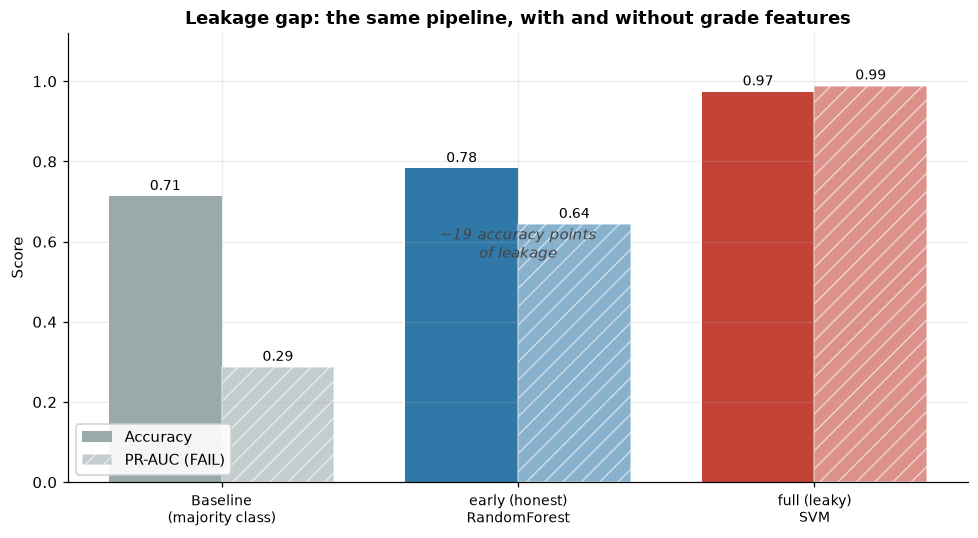

In [10]:
best = (results_df[results_df.model != "Baseline(most_frequent)"]
        .sort_values(f"pr_auc_{POS_LABEL}", ascending=False)
        .groupby("feature_set").first().reset_index())
base = results_df[results_df.model == "Baseline(most_frequent)"].iloc[0]

rows = [("Baseline\n(majority class)", base["accuracy"], base[f"pr_auc_{POS_LABEL}"], C_BASE)]
for _, r in best.sort_values("feature_set").iterrows():
    lbl = ("early (honest)\n" if r.feature_set == "early" else "full (leaky)\n") + r.model
    col = C_EARLY if r.feature_set == "early" else C_FULL
    rows.append((lbl, r["accuracy"], r[f"pr_auc_{POS_LABEL}"], col))

labels = [r[0] for r in rows]; x = np.arange(len(rows)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, [r[1] for r in rows], w, color=[r[3] for r in rows], alpha=.95, label="Accuracy")
b2 = ax.bar(x + w/2, [r[2] for r in rows], w, color=[r[3] for r in rows], alpha=.55,
            hatch="//", edgecolor="white", label=f"PR-AUC ({POS_LABEL})")
for bars in (b1, b2):
    ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=2)

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0, 1.12); ax.set_ylabel("Score")
ax.set_title("Leakage gap: the same pipeline, with and without grade features", fontweight="bold")
ax.legend(loc="lower left", framealpha=.9)
gap = rows[-1][1] - rows[1][1] if len(rows) > 2 else 0
ax.annotate(f"~{abs(gap)*100:.0f} accuracy points\nof leakage",
            xy=(0.5, 0.5), xycoords="axes fraction", ha="center",
            fontsize=10, style="italic", color="#444")
plt.tight_layout(); plt.show()

### Chart 2 — precision-recall curves (early models only)

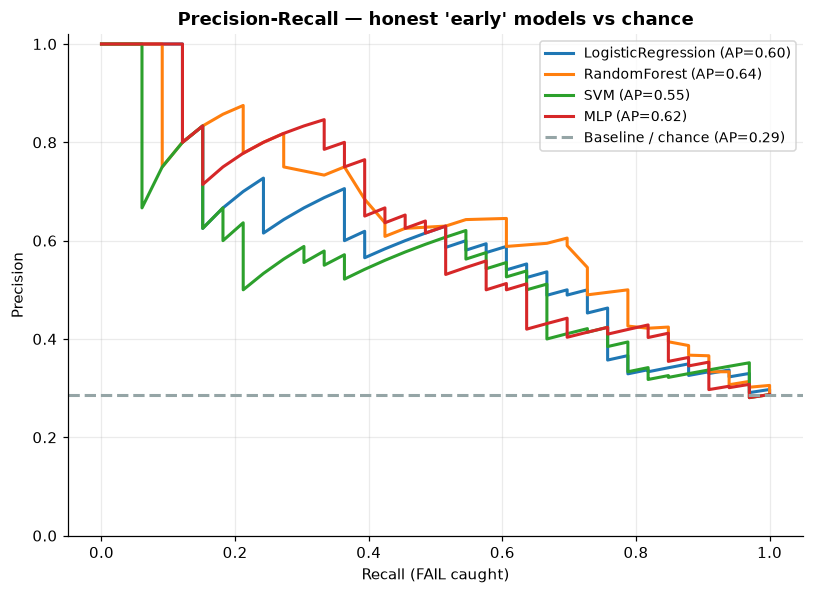

In [11]:
from sklearn.metrics import precision_recall_curve, average_precision_score

X_tr, X_te, y_tr, y_te = split(FEATURE_SETS["early"])
y_true = (y_te == POS_LABEL).astype(int)
prevalence = y_true.mean()

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for m_name in ["LogisticRegression", "RandomForest", "SVM", "MLP"]:
    pipe = fitted[("early", m_name)]
    s = pos_scores(pipe, X_te)
    if s is None: continue
    p, r, _ = precision_recall_curve(y_true, s)
    ap = average_precision_score(y_true, s)
    ax.plot(r, p, lw=2, label=f"{m_name} (AP={ap:.2f})")

ax.axhline(prevalence, ls="--", c=C_BASE, lw=2,
           label=f"Baseline / chance (AP={prevalence:.2f})")
ax.set_xlabel(f"Recall ({POS_LABEL} caught)"); ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall — honest 'early' models vs chance", fontweight="bold")
ax.set_ylim(0, 1.02); ax.legend(fontsize=9); plt.tight_layout(); plt.show()

### Chart 3 — what actually drives risk (interpretability)

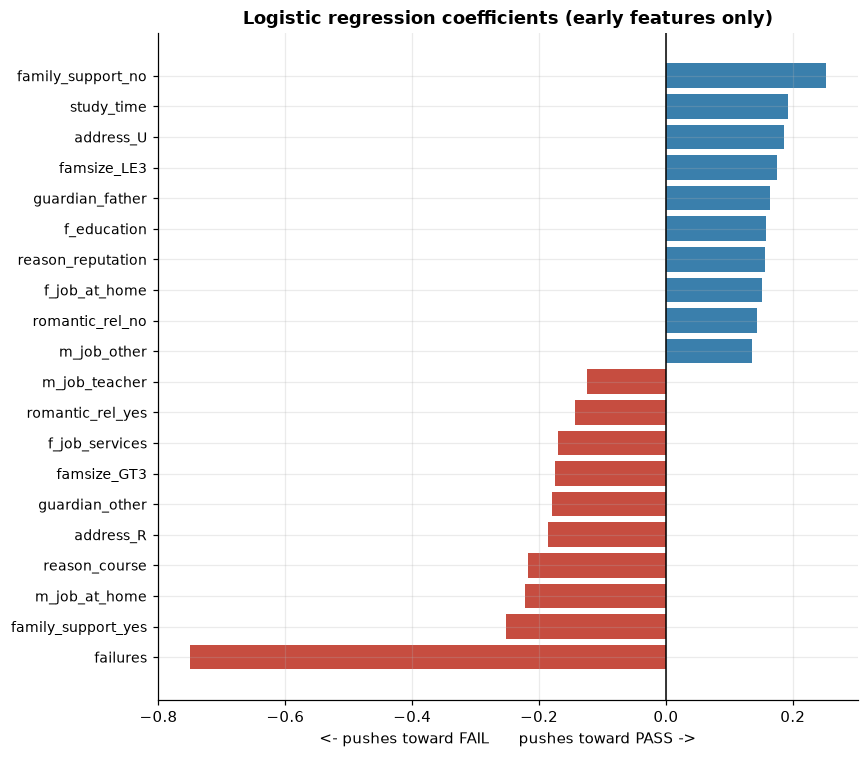

In [12]:
pipe = fitted[("early", "LogisticRegression")]
names = pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(pipe.named_steps["clf"].coef_.ravel(), index=names)
coefs.index = [n.split("__", 1)[-1] for n in coefs.index]

top = pd.concat([coefs.sort_values().head(10), coefs.sort_values().tail(10)])
colors = [C_FULL if v < 0 else C_EARLY for v in top.values]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(len(top)), top.values, color=colors, alpha=.9)
ax.set_yticks(range(len(top))); ax.set_yticklabels(top.index, fontsize=9)
ax.axvline(0, c="black", lw=1)
ax.set_xlabel(f"<- pushes toward {pipe.classes_[0]}      pushes toward {pipe.classes_[1]} ->")
ax.set_title("Logistic regression coefficients (early features only)", fontweight="bold")
plt.tight_layout(); plt.show()

### Chart 4 — why the decision threshold matters more than the model

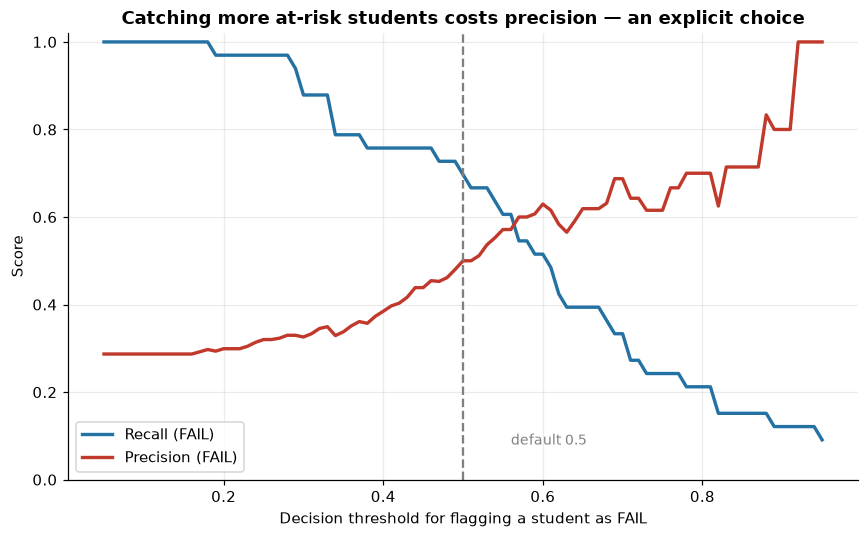

In [13]:
pipe = fitted[("early", "LogisticRegression")]
s = pos_scores(pipe, X_te)
ths = np.linspace(0.05, 0.95, 91)
rec = [recall_score(y_te, np.where(s >= t, POS_LABEL, pipe.classes_[1 - list(pipe.classes_).index(POS_LABEL)]),
                    pos_label=POS_LABEL, zero_division=0) for t in ths]
from sklearn.metrics import precision_score
pre = [precision_score(y_te, np.where(s >= t, POS_LABEL, pipe.classes_[1 - list(pipe.classes_).index(POS_LABEL)]),
                       pos_label=POS_LABEL, zero_division=0) for t in ths]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ths, rec, lw=2.2, c=C_EARLY, label=f"Recall ({POS_LABEL})")
ax.plot(ths, pre, lw=2.2, c=C_FULL, label=f"Precision ({POS_LABEL})")
ax.axvline(0.5, ls="--", c="grey", lw=1.5)
ax.annotate("default 0.5", xy=(0.5, 0.05), xytext=(0.56, 0.08), fontsize=9, color="grey")
ax.set_xlabel(f"Decision threshold for flagging a student as {POS_LABEL}")
ax.set_ylabel("Score"); ax.set_ylim(0, 1.02)
ax.set_title("Catching more at-risk students costs precision — an explicit choice",
             fontweight="bold")
ax.legend(); plt.tight_layout(); plt.show()

**How to read this table.** Expect `full` to post high accuracy — that's the leakage,
not skill. The `early` set is the honest picture: accuracy closer to the baseline, and
`recall_FAIL` / `pr_auc_FAIL` are the numbers to report, because catching at-risk
students is the whole point.

## 8. Best model per feature set — report + confusion matrix


=== full — best by PR-AUC: SVM ===
              precision    recall  f1-score   support

        FAIL       0.94      0.97      0.96        33
        PASS       0.99      0.98      0.98        82

    accuracy                           0.97       115
   macro avg       0.96      0.97      0.97       115
weighted avg       0.97      0.97      0.97       115



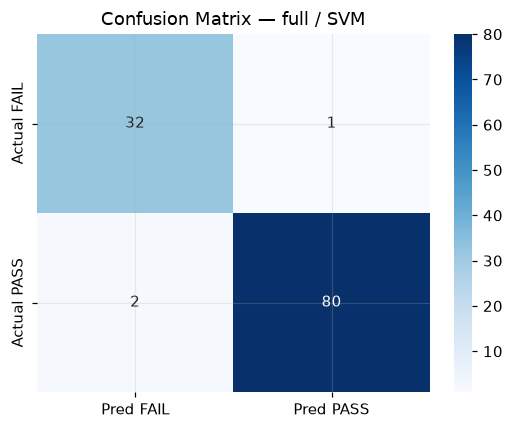


=== early — best by PR-AUC: RandomForest ===
              precision    recall  f1-score   support

        FAIL       0.64      0.55      0.59        33
        PASS       0.83      0.88      0.85        82

    accuracy                           0.78       115
   macro avg       0.74      0.71      0.72       115
weighted avg       0.77      0.78      0.78       115



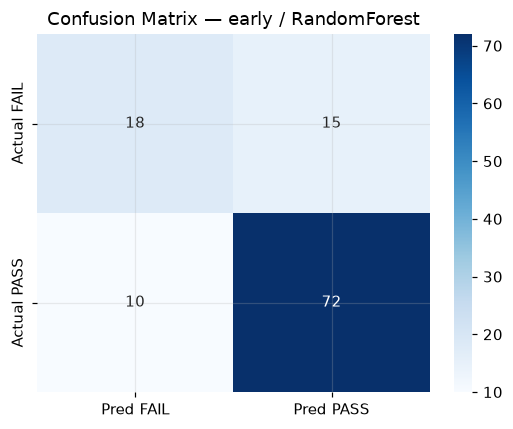

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

for fs_name in FEATURE_SETS:
    sub = results_df[(results_df.feature_set == fs_name) &
                     (results_df.model != "Baseline(most_frequent)")]
    best = sub.iloc[0]["model"]                      # already sorted by PR-AUC
    pipe = fitted[(fs_name, best)]
    _, X_te, _, y_te = split(FEATURE_SETS[fs_name])
    y_pred = pipe.predict(X_te)
    labels = list(pipe.classes_)                     # real order, never hardcoded

    print(f"\n=== {fs_name} — best by PR-AUC: {best} ===")
    print(classification_report(y_te, y_pred, labels=labels,
                                target_names=labels, zero_division=0))

    cm = confusion_matrix(y_te, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"Actual {l}" for l in labels],
                             columns=[f"Pred {l}" for l in labels])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix — {fs_name} / {best}")
    plt.tight_layout(); plt.show()

## 9. What drives the honest (early) model — logistic coefficients

In [15]:
pipe = fitted[("early", "LogisticRegression")]
names = pipe.named_steps["prep"].get_feature_names_out()
coefs = pd.Series(pipe.named_steps["clf"].coef_.ravel(), index=names)

print(f"Top features pushing toward {pipe.classes_[1]}:")
print(coefs.sort_values(ascending=False).head(10).round(3))
print(f"\nTop features pushing toward {pipe.classes_[0]}:")
print(coefs.sort_values().head(10).round(3))

Top features pushing toward PASS:
onehot__family_support_no    0.253
scaler__study_time           0.192
onehot__address_U            0.186
onehot__famsize_LE3          0.176
onehot__guardian_father      0.164
scaler__f_education          0.157
onehot__reason_reputation    0.157
onehot__f_job_at_home        0.151
onehot__romantic_rel_no      0.143
onehot__m_job_other          0.135
dtype: float64

Top features pushing toward FAIL:
scaler__failures             -0.751
onehot__family_support_yes   -0.252
onehot__m_job_at_home        -0.223
onehot__reason_course        -0.218
onehot__address_R            -0.186
onehot__guardian_other       -0.179
onehot__famsize_GT3          -0.175
onehot__f_job_services       -0.170
onehot__romantic_rel_yes     -0.143
onehot__m_job_teacher        -0.124
dtype: float64


## 10. Optional: tune the early model for FAIL recall

In [16]:
import warnings
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer

fail_recall = make_scorer(recall_score, pos_label=POS_LABEL, zero_division=0)
X_tr, X_te, y_tr, y_te = split(FEATURE_SETS["early"])

# This search scores on FAIL-recall, which only needs predict() -- no probabilities --
# so plain SVC is used here (no deprecated probability=True, and it's faster).
grid_pipe = Pipeline([("prep", build_preprocessor(df, FEATURE_SETS["early"])),
                      ("clf", SVC(kernel="rbf", class_weight="balanced",
                                  random_state=RANDOM_STATE))])
param_grid = {"clf__C": [0.1, 1, 10, 100], "clf__gamma": [1, 0.1, 0.01, 0.001]}
gs = GridSearchCV(grid_pipe, param_grid, cv=5, scoring=fail_recall, n_jobs=-1)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")      # hide cosmetic convergence/version notices
    gs.fit(X_tr, y_tr)
    y_pred_gs = gs.predict(X_te)

print("Best params:", gs.best_params_)
print(f"Best CV FAIL-recall: {gs.best_score_:.3f}")
print(f"Held-out FAIL-recall: {recall_score(y_te, y_pred_gs, pos_label=POS_LABEL, zero_division=0):.3f}")

Best params: {'clf__C': 100, 'clf__gamma': 0.001}
Best CV FAIL-recall: 0.532
Held-out FAIL-recall: 0.636


## 11. Save each fitted model to its own file

In [17]:
import joblib, os
os.makedirs("saved_models", exist_ok=True)
for (fs_name, m_name), pipe in fitted.items():
    path = f"saved_models/{fs_name}__{m_name}.joblib"
    joblib.dump(pipe, path)
    print("saved", path)

saved saved_models/full__LogisticRegression.joblib
saved saved_models/full__RandomForest.joblib
saved saved_models/full__SVM.joblib
saved saved_models/full__MLP.joblib
saved saved_models/full__SGD.joblib
saved saved_models/early__LogisticRegression.joblib
saved saved_models/early__RandomForest.joblib
saved saved_models/early__SVM.joblib
saved saved_models/early__MLP.joblib
saved saved_models/early__SGD.joblib


## 12. Takeaways

- Report the **early** model as the real result, with **FAIL recall** and **PR-AUC**
  as headline metrics against the majority baseline.
- The **full** model is kept only to show, explicitly, how much of the apparent
  accuracy comes from leakage.
- The saved-model files are named `{feature_set}__{model}.joblib` — load the one the
  app should actually serve (most likely an `early__*` model).

## Appendix A — (Optional) fetch the ORIGINAL source dataset for provenance

Reference only. This pulls the original UCI Student Performance data (auth-free, no
Kaggle account). Its schema differs from `updated_data.xlsx` (single-subject grades
G1/G2/G3, original column names), so it is **not** a drop-in for the model above —
it exists so a reviewer can trace the lineage. UCI's own notes flag that G3 is
strongly correlated with G1/G2, which is the leakage this notebook is careful about.

In [18]:
# !pip install ucimlrepo    # uncomment on first run
from ucimlrepo import fetch_ucirepo

student_performance = fetch_ucirepo(id=320)   # UCI id 320, CC BY 4.0
source = student_performance.data.original
print("Original source shape:", source.shape)
print("Original columns:", list(source.columns))
source.head()

Original source shape: (649, 33)
Original columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
